In [75]:
import numpy as np
import pandas as pd

In [76]:
df = pd.read_csv(r'placement.csv')

In [77]:
df.head()

,cgpa,iq,internship,projects,dsa_rating,placement
0,8.27,119,0,4,1659,0
1,6.64,86,0,2,980,0
2,8.81,124,0,3,1230,0
3,8.14,130,0,2,1625,1
4,7.11,122,0,2,1202,0


In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   cgpa        3000 non-null   float64
 1   iq          3000 non-null   int64  
 2   internship  3000 non-null   int64  
 3   projects    3000 non-null   int64  
 4   dsa_rating  3000 non-null   int64  
 5   placement   3000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 140.8 KB


In [79]:
df.shape

(3000, 6)

In [80]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns


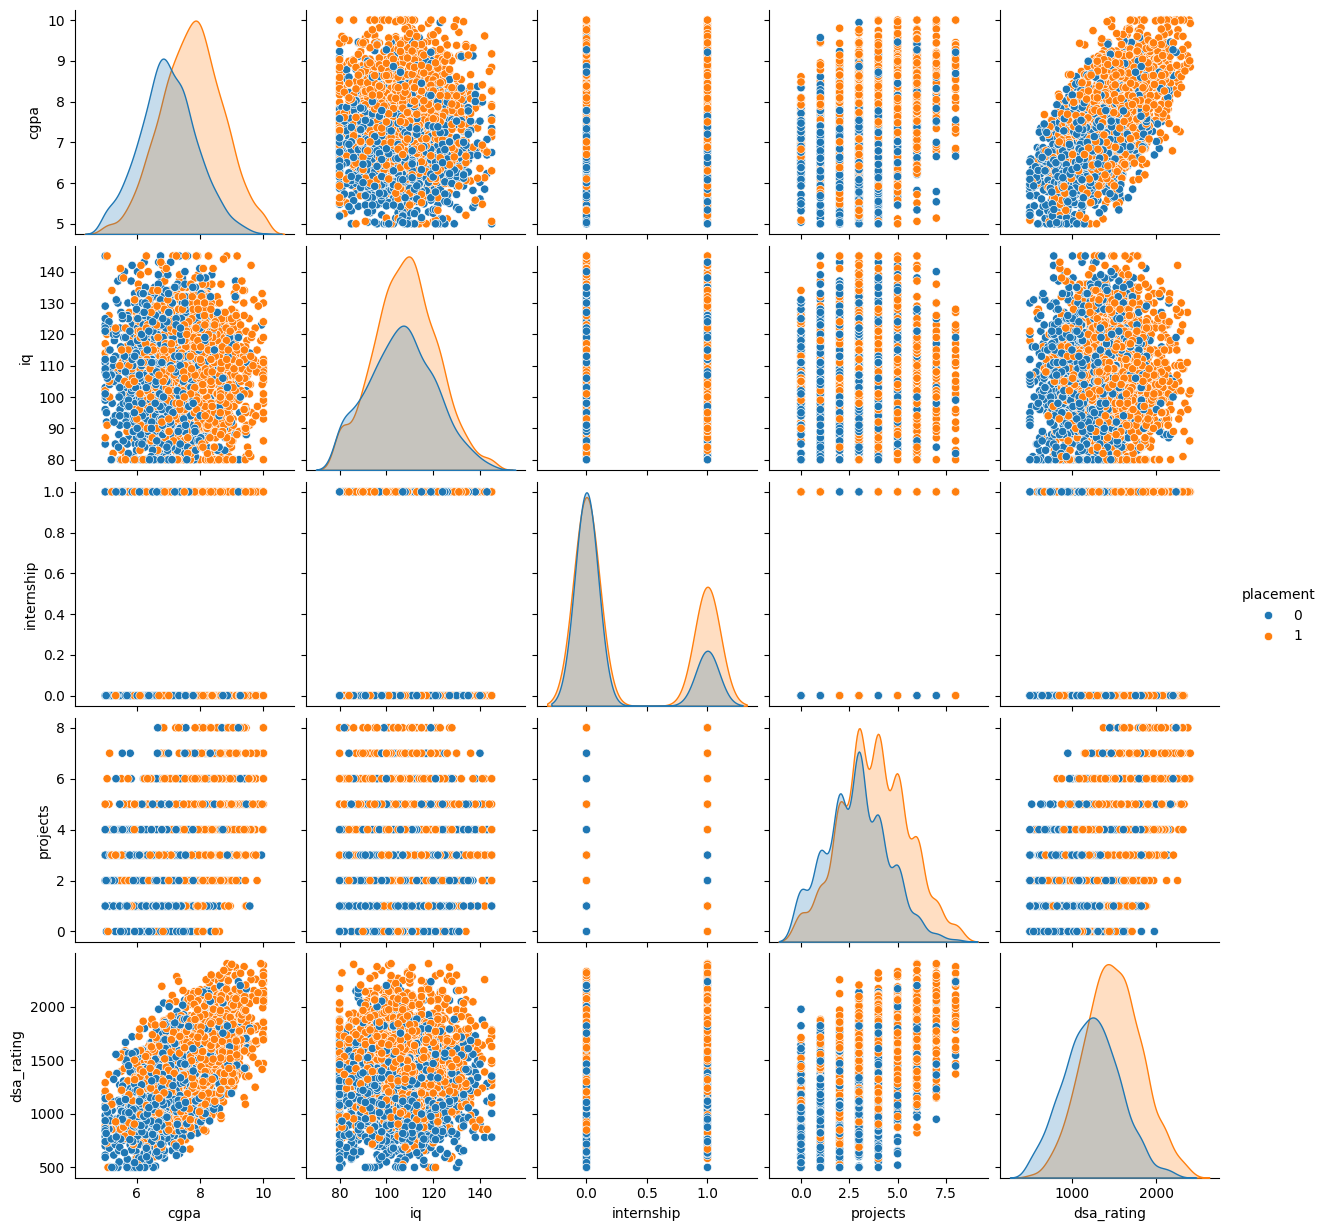

In [82]:
sns.pairplot(
    df,
    hue='placement'
)

plt.show()

In [83]:
X = df.iloc[:,0:5]
y = df.iloc[:,-1]


In [84]:
X

,cgpa,iq,internship,projects,dsa_rating
0,8.27,119,0,4,1659
1,6.64,86,0,2,980
2,8.81,124,0,3,1230
3,8.14,130,0,2,1625
4,7.11,122,0,2,1202
...,...,...,...,...,...
2995,6.08,107,1,3,1117
2996,8.72,106,0,4,1752
2997,9.44,90,1,7,1964
2998,7.78,98,0,2,1399


In [85]:
y.shape

(3000,)

In [86]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [87]:
X_train

,cgpa,iq,internship,projects,dsa_rating
2499,8.43,123,0,4,1043
1072,7.53,114,0,4,868
2731,9.98,107,0,4,1989
929,7.81,103,0,4,1401
2738,5.52,115,0,3,1220
...,...,...,...,...,...
220,6.58,116,0,4,1671
92,5.81,117,0,2,1000
272,7.20,105,0,3,1767
2999,8.09,84,0,2,1299


In [88]:
y_train

2499    0
1072    1
2731    1
929     1
2738    1
       ..
220     0
92      1
272     1
2999    1
1369    1
Name: placement, Length: 2400, dtype: int64

In [89]:
X_test

,cgpa,iq,internship,projects,dsa_rating
2975,5.69,91,0,1,500
115,7.05,126,1,4,1088
2170,7.26,99,0,0,1251
2017,6.33,95,0,3,913
2951,8.23,108,0,2,1296
...,...,...,...,...,...
576,8.02,112,0,1,1427
330,9.44,106,1,5,2152
349,8.05,103,0,3,1473
1641,9.32,137,1,6,2044


In [90]:
from sklearn.preprocessing import StandardScaler

In [91]:
scaler = StandardScaler()

In [92]:
X_train = scaler.fit_transform(X_train)

In [93]:
X_train

array([[ 1.01152608,  1.11821561, -0.64363069,  0.35077179, -0.94320763],
       [ 0.1167735 ,  0.46130043, -0.64363069,  0.35077179, -1.43829324],
       [ 2.55248886, -0.04963359, -0.64363069,  0.35077179,  1.73308372],
       ...,
       [-0.21130245, -0.19561474, -0.64363069, -0.22941587,  1.10503226],
       [ 0.67350844, -1.72841681, -0.64363069, -0.80960352, -0.21896811],
       [-0.84757095, -0.34159589, -0.64363069, -1.38979117, -0.87813924]],
      shape=(2400, 5))

In [94]:
X_test = scaler.transform(X_test)

In [95]:
X_test

array([[-1.71249845, -1.21748279, -0.64363069, -1.38979117, -2.47938755],
       [-0.36042788,  1.33718733,  1.55368602,  0.35077179, -0.8158999 ],
       [-0.15165228, -0.63355819, -0.64363069, -1.96997883, -0.35476302],
       ...,
       [ 0.63374166, -0.34159589, -0.64363069, -0.22941587,  0.27328843],
       [ 1.89633697,  2.14008365,  1.55368602,  1.51114709,  1.88868205],
       [ 0.44484944, -2.02037911,  1.55368602,  0.93095944, -0.20199375]],
      shape=(600, 5))

In [96]:
from sklearn.linear_model import LogisticRegression

In [97]:
clf = LogisticRegression()

In [98]:
# model training
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [99]:
y_pred = clf.predict(X_test)

In [100]:
y_test

2975    0
115     1
2170    1
2017    0
2951    1
       ..
576     1
330     0
349     1
1641    1
18      1
Name: placement, Length: 600, dtype: int64

In [101]:
from sklearn.metrics import accuracy_score

In [102]:
accuracy_score(y_test,y_pred)

0.7066666666666667

In [103]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [104]:
cm = confusion_matrix(y_test, y_pred)

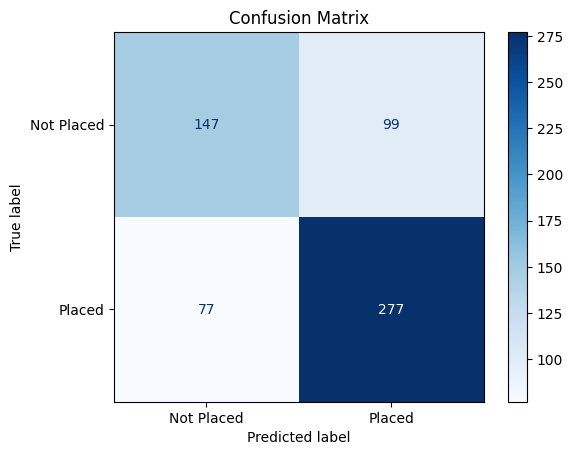

In [105]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Placed", "Placed"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [106]:
import pickle

In [107]:
pickle.dump(clf,open('model.pkl','wb'))

In [108]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [109]:
print(scaler.n_features_in_)

5
